Dataset sources:

  English: https://www.kaggle.com/datasets/dhruvildave/english-handwritten-characters-dataset

  Arabic: https://www.kaggle.com/datasets/mloey1/ahcd1

  Chinese: https://www.kaggle.com/datasets/vitaliikyzym/chinese-handwriting-recognition-hsk-1

In [1]:
!pip install kagglehub

In [2]:
import kagglehub
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np


In [3]:
plt.rcParams["font.family"] = "Arial Unicode MS"
random.seed(42)

In [4]:
ENGLISH_PATH = kagglehub.dataset_download("dhruvildave/english-handwritten-characters-dataset")
ARABIC_PATH = kagglehub.dataset_download("mloey1/ahcd1")
CHINESE_PATH = kagglehub.dataset_download("vitaliikyzym/chinese-handwriting-recognition-hsk-1")

In [5]:
ENGLISH_START_INDEX = 37
ENGLISH_IMG_DIR = f"{ENGLISH_PATH}/Img"
ENGLISH_ALL_IMGS = os.listdir(ENGLISH_IMG_DIR)

ENGLISH_IMG_DICT = {}

for i, character in enumerate("abcdefghijklmnopqrstuvwxyz"):
    ENGLISH_IMG_DICT[character] = [
        img for img in ENGLISH_ALL_IMGS if img.startswith(f"img0{ENGLISH_START_INDEX + i}")
    ]
    print(
        f"{character}: "
        f"{sum(1 for _ in ENGLISH_IMG_DICT[character])}"
    )

a: 55
b: 55
c: 55
d: 55
e: 55
f: 55
g: 55
h: 55
i: 55
j: 55
k: 55
l: 55
m: 55
n: 55
o: 55
p: 55
q: 55
r: 55
s: 55
t: 55
u: 55
v: 55
w: 55
x: 55
y: 55
z: 55


In [6]:
ARABIC_START_INDEX = 1
ARABIC_IMG_DIR = f"{ARABIC_PATH}/Test Images 3360x32x32/test"
ARABIC_ALL_IMGS = os.listdir(ARABIC_IMG_DIR)

ARABIC_IMG_DICT = {}

for i, character in enumerate("ابتثجحخدذرزسشصضطظعغفقكلمنهوي"):
    label_num = ARABIC_START_INDEX + i

    ARABIC_IMG_DICT[character] = [
        img for img in ARABIC_ALL_IMGS
        if img.endswith(f"label_{label_num}.png")
    ]

    print(f"({character}): {len(ARABIC_IMG_DICT[character])}", )

(ا): 120
(ب): 120
(ت): 120
(ث): 120
(ج): 120
(ح): 120
(خ): 120
(د): 120
(ذ): 120
(ر): 120
(ز): 120
(س): 120
(ش): 120
(ص): 120
(ض): 120
(ط): 120
(ظ): 120
(ع): 120
(غ): 120
(ف): 120
(ق): 120
(ك): 120
(ل): 120
(م): 120
(ن): 120
(ه): 120
(و): 120
(ي): 120


In [7]:
CHINESE_IMG_DIR = f"{CHINESE_PATH}/chinese-handwriting/CASIA-HWDB_Test/Test"
CHINESE_ALL_CHARACTERS = os.listdir(CHINESE_IMG_DIR)

CHINESE_SUBSET_CHARACTERS = random.sample(CHINESE_ALL_CHARACTERS, 30)

CHINESE_IMG_DICT = {}

for character in CHINESE_SUBSET_CHARACTERS:

    fixed_character = character.encode("cp437").decode("utf-8")

    CHINESE_IMG_DICT[fixed_character] = [os.path.join(character, img)for img in os.listdir(os.path.join(CHINESE_IMG_DIR, character))]

    print(f"{fixed_character}: {len(CHINESE_IMG_DICT[fixed_character])}", )


漂: 144
们: 143
好: 142
住: 143
个: 142
不: 142
叫: 143
儿: 142
后: 143
分: 142
中: 143
客: 143
学: 144
视: 143
西: 142
东: 142
很: 143
那: 144
爱: 141
欢: 142
星: 142
吃: 142
觉: 143
机: 143
看: 145
钱: 144
商: 144
写: 143
面: 142
八: 143


In [8]:
def display_sample_images(img_dict, img_dir):
    fig, axes = plt.subplots(5, 5, figsize=(6, 6))

    for row, character in enumerate(list(img_dict.keys())[:5]):
        imgs = img_dict[character]

        sample_imgs = random.sample(imgs, 5)

        for col in range(5):
            ax = axes[row][col]
            ax.axis("off")

            img_path = os.path.join(img_dir, sample_imgs[col])
            img = Image.open(img_path)

            ax.imshow(img, cmap="gray")

    plt.tight_layout()
    plt.show()

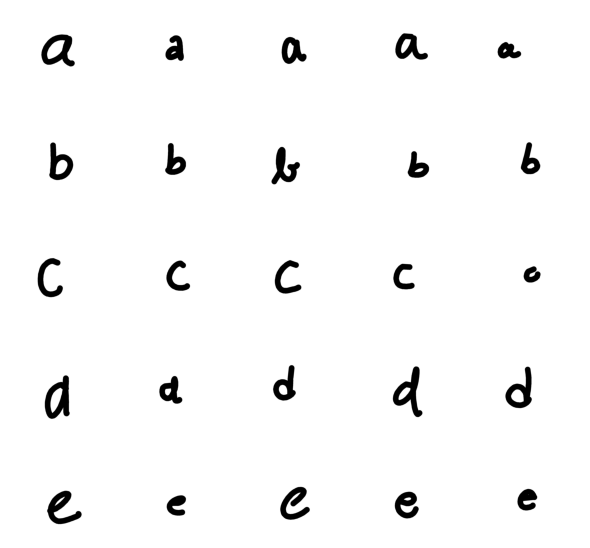

In [9]:
display_sample_images(ENGLISH_IMG_DICT, ENGLISH_IMG_DIR)

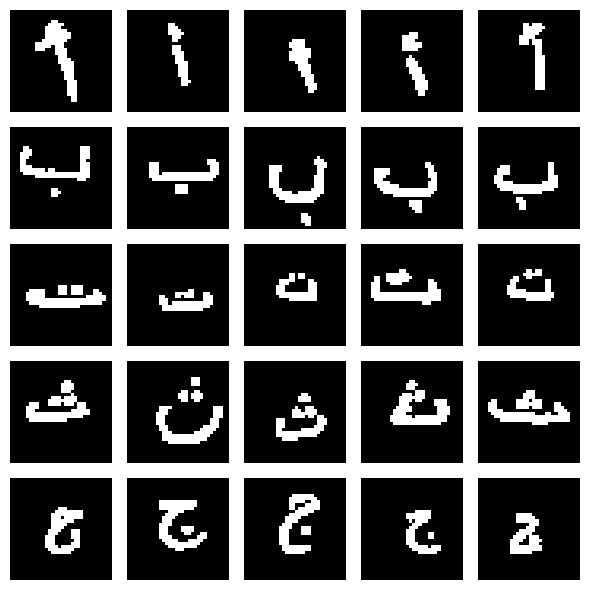

In [10]:
display_sample_images(ARABIC_IMG_DICT, ARABIC_IMG_DIR)

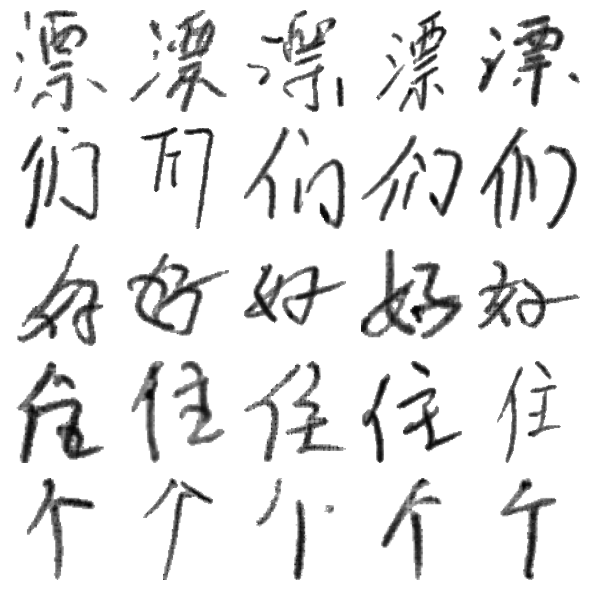

In [11]:
display_sample_images(CHINESE_IMG_DICT, CHINESE_IMG_DIR)

In [12]:
def process_character(img_path, output_size, invert, threshold=128, margin_ratio=0.1):
    img = Image.open(img_path).convert("L")
    arr = np.array(img)

    if not invert:
        binary = (arr < threshold).astype(np.uint8)
    else:
        binary = (arr > threshold).astype(np.uint8)

    coords = np.argwhere(binary == 1)

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    cropped = binary[y_min:y_max + 1, x_min:x_max + 1]
    h, w = cropped.shape

    margin = round(output_size * margin_ratio)
    inner_size = output_size - 2 * margin

    scale = inner_size / max(h, w)

    new_h = max(1, round(h * scale))
    new_w = max(1, round(w * scale))

    cropped_img = Image.fromarray((cropped * 255).astype(np.uint8))
    resized_img = cropped_img.resize((new_w, new_h), Image.NEAREST)
    resized = (np.array(resized_img) > 0).astype(np.uint8)

    canvas = np.zeros((output_size, output_size), dtype=np.uint8)

    y_offset = (output_size - new_h) // 2
    x_offset = (output_size - new_w) // 2

    canvas[y_offset:y_offset + new_h, x_offset:x_offset + new_w] = resized

    return canvas

In [13]:
def process_language(img_dict, img_dir, output_size, invert):
    processed_img_dict = {}
    for character in img_dict:
        processed_img_dict[character] = []

        for img_name in img_dict[character]:
            img_path = os.path.join(img_dir, img_name)
            final_img = process_character(img_path, output_size=output_size, invert=invert)
            processed_img_dict[character].append(final_img)

    return processed_img_dict

def display_sample_processed_images(processed_img_dict):
    fig, axes = plt.subplots(5, 5, figsize=(6, 6))

    for row, character in enumerate(list(processed_img_dict.keys())[:5]):
        imgs = processed_img_dict[character]
        sample_imgs = random.sample(imgs, 5)

        for col in range(5):
            ax = axes[row][col]
            ax.axis("off")

            ax.imshow(sample_imgs[col], cmap="gray")

    plt.tight_layout()
    plt.show()

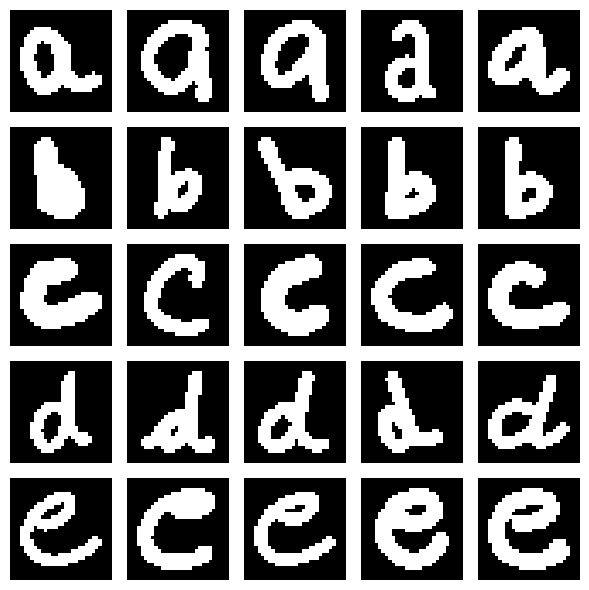

In [14]:
english_processed_img_dict = process_language(ENGLISH_IMG_DICT, ENGLISH_IMG_DIR, output_size=30, invert=False)
display_sample_processed_images(english_processed_img_dict)

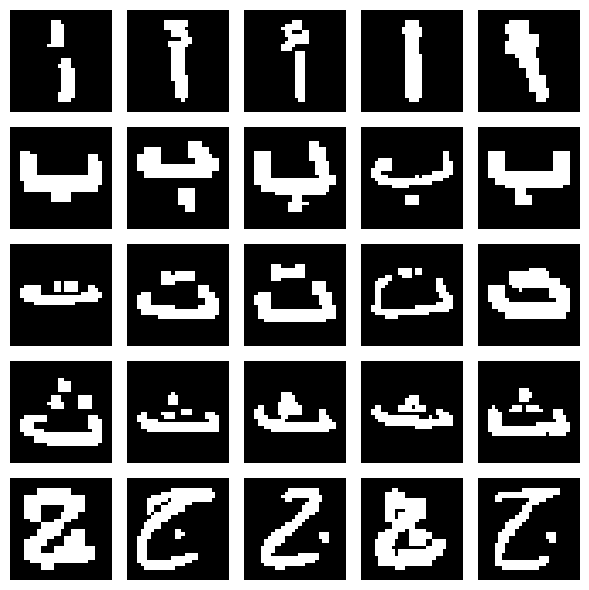

In [15]:
arabic_processed_img_dict = process_language(ARABIC_IMG_DICT, ARABIC_IMG_DIR, output_size=30, invert=True)
display_sample_processed_images(arabic_processed_img_dict)

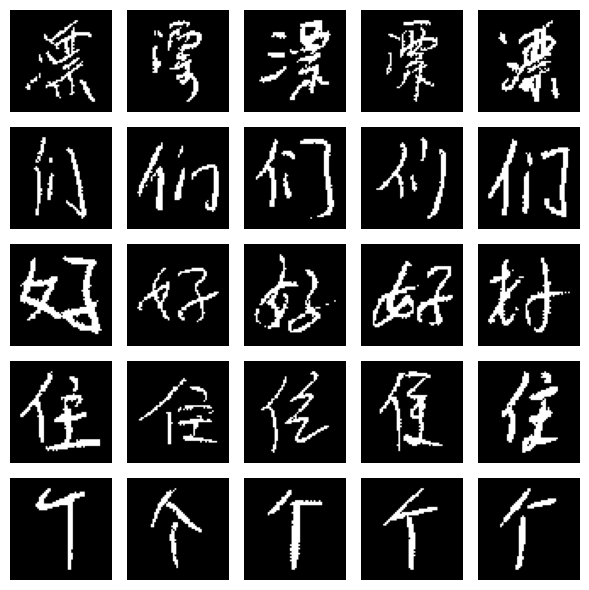

In [16]:
chinese_processed_img_dict = process_language(CHINESE_IMG_DICT, CHINESE_IMG_DIR, output_size=60, invert=False)
display_sample_processed_images(chinese_processed_img_dict)

In [17]:
def calculate_mean_image(processed_img_dict):
    mean_img_dict = {}

    for character, imgs in processed_img_dict.items():
        mean_img = np.mean(imgs, axis=0)
        max_val = np.max(mean_img)
        mean_img = mean_img / max_val
        
        mean_img_dict[character] = mean_img

    return mean_img_dict

def display_mean_images(mean_img_dict):
    fig, axes = plt.subplots(5, 6, figsize=(6, 6))
    axes = axes.flatten()

    for i, character in enumerate(list(mean_img_dict.keys())):
        axes[i].imshow(mean_img_dict[character], cmap="gray_r", vmin=0, vmax=1)
        axes[i].set_title(character)
        axes[i].axis("off")

    for i in range(30):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

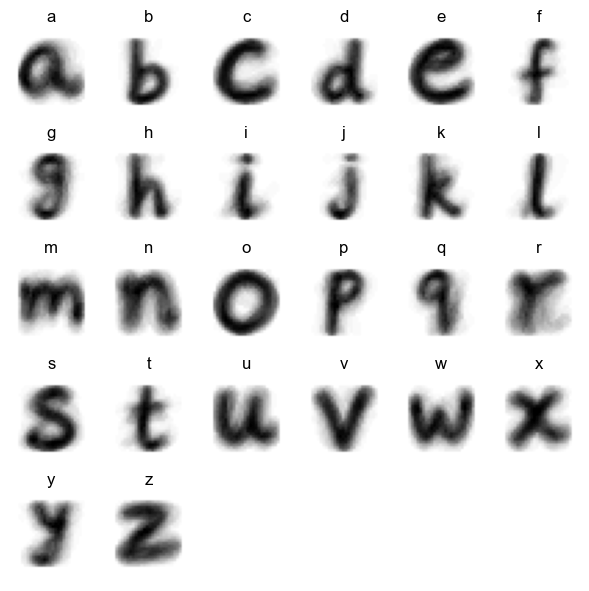

In [18]:
english_mean_img_dict = calculate_mean_image(english_processed_img_dict)
display_mean_images(english_mean_img_dict)

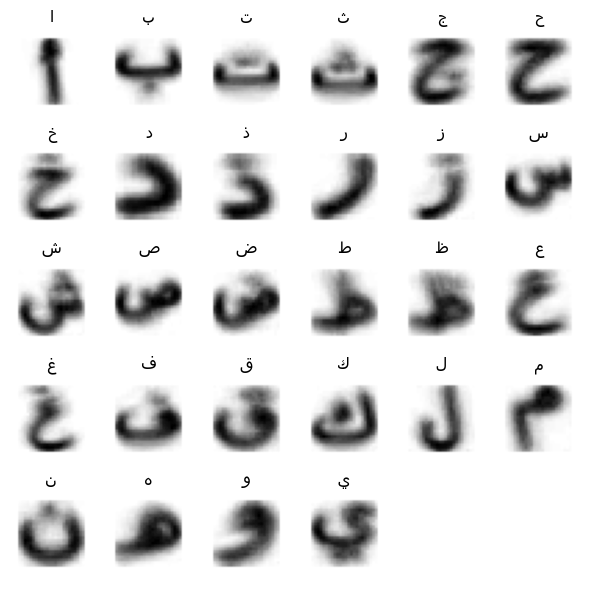

In [19]:
arabic_mean_img_dict = calculate_mean_image(arabic_processed_img_dict)
display_mean_images(arabic_mean_img_dict)

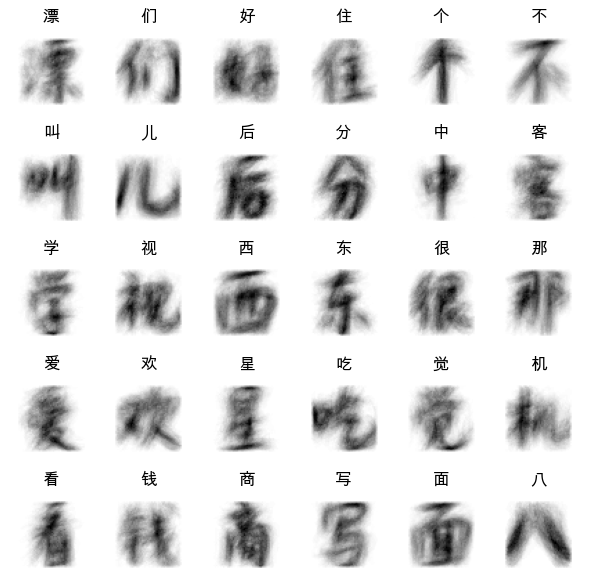

In [20]:
chinese_mean_img_dict = calculate_mean_image(chinese_processed_img_dict)
display_mean_images(chinese_mean_img_dict)

In [26]:
def calculate_variation(processed_img_dict, mean_img_dict, active_threshold=0.1):
    variation_dict = {}

    for character in processed_img_dict:
        mean_img = mean_img_dict[character]
        active_region = mean_img > active_threshold

        scores = []

        for img in processed_img_dict[character]:
            score = np.mean((img[active_region] - mean_img[active_region]) ** 2)
            scores.append(score)

        variation_dict[character] = np.mean(scores)

    return variation_dict

def display_variation(variation_dict):
    characters = list(variation_dict.keys())
    scores = list(variation_dict.values())

    plt.figure(figsize=(12, 6))
    plt.bar(characters, scores)
    plt.xlabel("Character")
    plt.ylabel("Average Squared Deviation")
    plt.title("Variation of Handwriting for Each Character")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

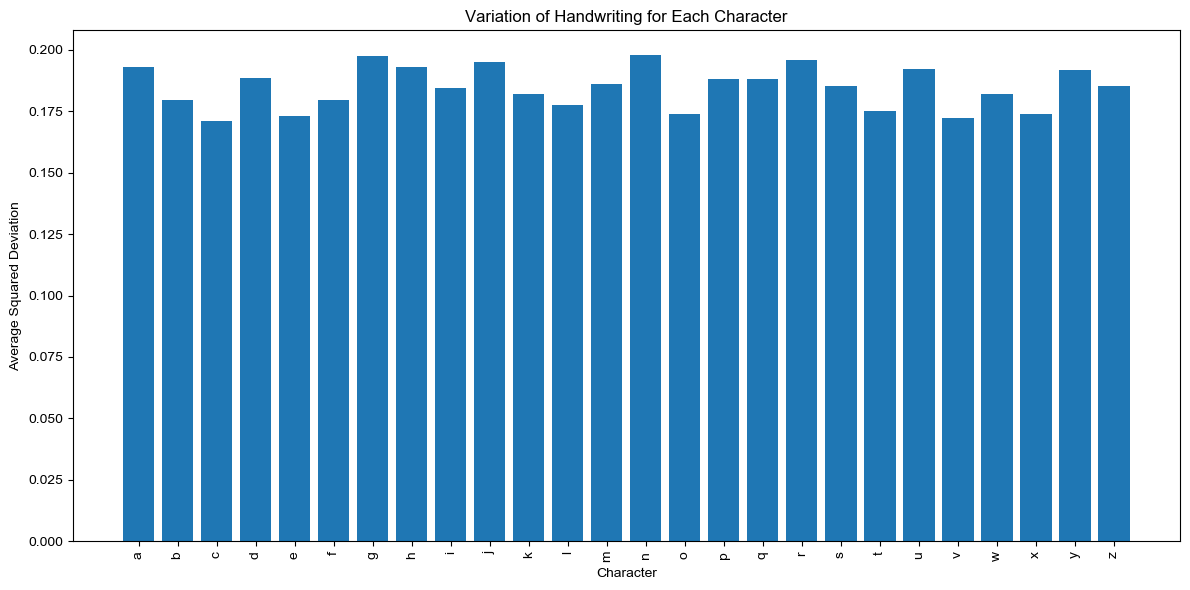

In [27]:
english_scores = calculate_variation(english_processed_img_dict, english_mean_img_dict)
display_variation(english_scores)

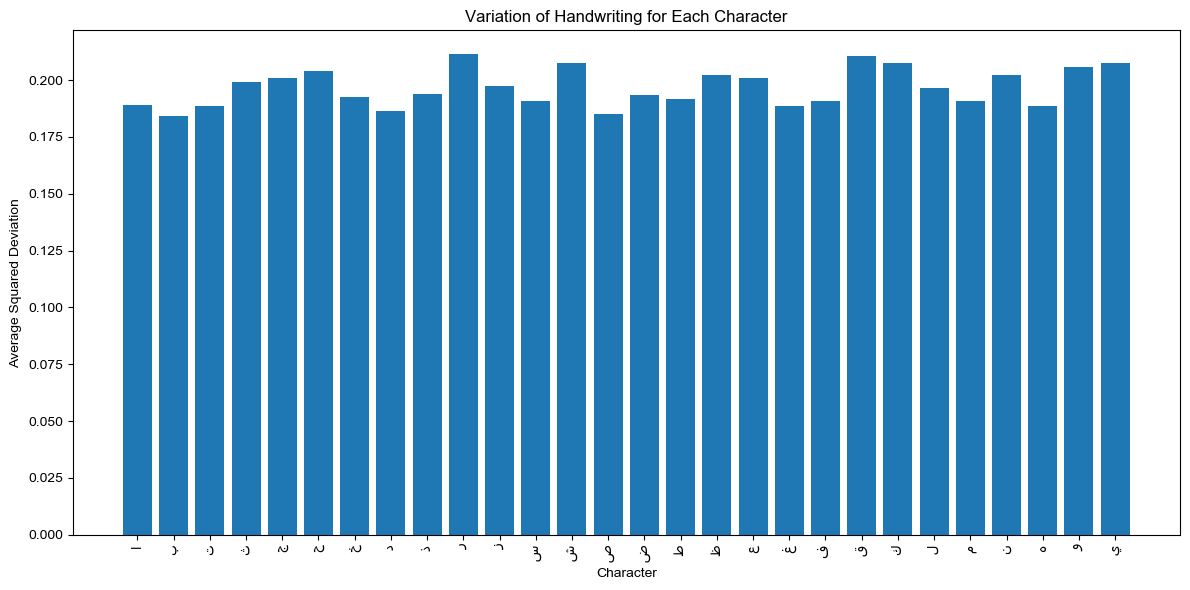

In [28]:
arabic_scores = calculate_variation(arabic_processed_img_dict, arabic_mean_img_dict)
display_variation(arabic_scores)

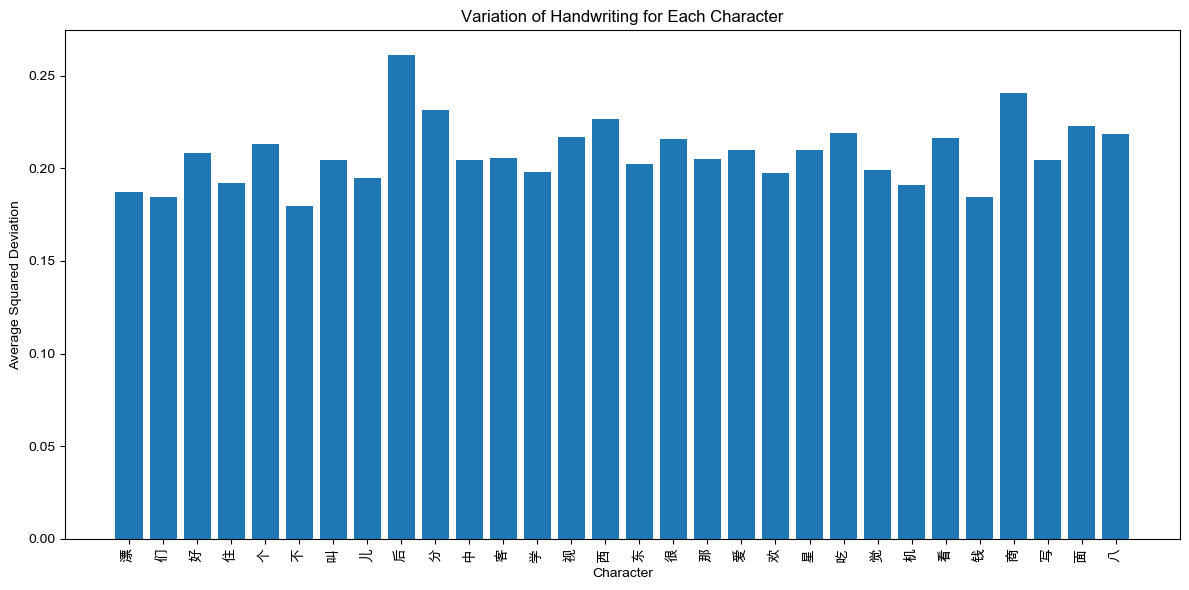

In [29]:
chinese_scores = calculate_variation(chinese_processed_img_dict, chinese_mean_img_dict)
display_variation(chinese_scores)

In [30]:
print("English average variation:", np.mean(list(english_scores.values())))
print("Arabic average variation:", np.mean(list(arabic_scores.values())))
print("Chinese average variation:", np.mean(list(chinese_scores.values())))

English average variation: 0.18473690611586951
Arabic average variation: 0.196635339101191
Chinese average variation: 0.2082085255280825


In [31]:
print("English std variation:", np.std(list(english_scores.values())))
print("Arabic std variation:", np.std(list(arabic_scores.values())))
print("Chinese std variation:", np.std(list(chinese_scores.values())))

English std variation: 0.008289724774638973
Arabic std variation: 0.00805758063270397
Chinese std variation: 0.017272988124055304
